In [1]:
import pandas as pd
import numpy as np
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from datetime import timedelta

## Таблица olist_customers_dataset

In [2]:
customers_df = pd.read_csv('olist_customers_dataset.csv')

**olist_customers_dataset.csv** — таблица с уникальными идентификаторами пользователей

- customer_id — позаказный идентификатор пользователя
- customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)
- customer_zip_code_prefix — почтовый индекс пользователя
- customer_city — город доставки пользователя
- customer_state — штат доставки пользователя

In [3]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers_df.shape

(99441, 5)

In [5]:
customers_df.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [6]:
# смотрим на количество уникальных значений в каждой колонке
customers_df.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [7]:
customers_df.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Таблица olist_orders_dataset

In [8]:
orders_df = pd.read_csv('olist_orders_dataset.csv')

**olist_orders_dataset.csv** —  таблица заказов

- order_id — уникальный идентификатор заказа (номер чека)
- customer_id — позаказный идентификатор пользователя
- **order_status** — статус заказа
- order_purchase_timestamp — время создания заказа
- order_approved_at — время подтверждения оплаты заказа
- order_delivered_carrier_date — время передачи заказа в логистическую службу
- order_delivered_customer_date — время доставки заказа
- order_estimated_delivery_date — обещанная дата доставки

Уникальные статусы заказов (**order_status**) в таблице olist_orders_dataset:

- created — создан;
- approved — подтверждён;
- invoiced — выставлен счёт;
- processing — в процессе сборки заказа;
- shipped — отгружён со склада;
- delivered — доставлен пользователю;
- unavailable — заказ отменён по причине недоступности товара;;
- canceled — отменён.

In [9]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders_df.shape

(99441, 8)

In [11]:
# смотрим на количество уникальных значений в каждой колонке
orders_df.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [12]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [13]:
orders_df.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [14]:
# приводим даты к нужному типу

# время создания заказа
orders_df.order_purchase_timestamp = pd.to_datetime(orders_df.order_purchase_timestamp)
# время подтверждения оплаты заказа
orders_df.order_approved_at = pd.to_datetime(orders_df.order_approved_at)
# время передачи заказа в логистическую службу
orders_df.order_delivered_carrier_date = pd.to_datetime(orders_df.order_delivered_carrier_date)
# время доставки заказа
orders_df.order_delivered_customer_date = pd.to_datetime(orders_df.order_delivered_customer_date)
# обещанная дата доставки
orders_df.order_estimated_delivery_date = pd.to_datetime(orders_df.order_estimated_delivery_date)

In [15]:
orders_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [16]:
# смотрим описание по категориальным переменным
orders_df.describe(include='object')

,order_id,customer_id,order_status
count,99441,99441,99441
unique,99441,99441,8
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered
freq,1,1,96478


In [17]:
# смотрим описание по переменным даты
orders_df.describe(include='datetime')

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


## Таблица olist_order_items_dataset

In [18]:
order_items_df = pd.read_csv('olist_order_items_dataset.csv')

**olist_order_items_dataset.csv** — товарные позиции, входящие в заказы

- order_id — уникальный идентификатор заказа (номер чека)
- order_item_id — идентификатор товара внутри одного заказа
- product_id — ид товара (аналог штрихкода)
- seller_id — ид производителя товара
- shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике
- price — цена за единицу товара
- freight_value — вес товара 

In [19]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [20]:
order_items_df.shape

(112650, 7)

In [21]:
order_items_df.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [22]:
order_items_df.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [23]:
order_items_df.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [24]:
# приводим максимальную дату доставки продавцом для передачи заказа партнеру по логистике к нужному типу
order_items_df.shipping_limit_date = pd.to_datetime(order_items_df.shipping_limit_date)

In [25]:
order_items_df.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

---

## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

**Для этого вам нужно:**

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

**В рамках исследования необходимо:**

- Исследовать датасет и определить, какой вид заказа будет учитываться в retention
- Построить месячный retention
- Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
- Найти когорту с самым высоким retention на 3-й месяц.
- Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

### Решение (задача 1)

Для определения месячного retention в оформление заказа, возьмём дату создания заказа пользователем. Именно это и будет дата необходимого нам активного действия. 

На данном этапе статус заказа не имеет значения, ведь для распределения юзеров на когорты, чтобы оценить месячный retention **в оформление заказа**, нам понадобится только дата, когда заказы были созданы. Оформление заказа = создание заказа

In [26]:
# выделяем данные, которые нам понадобятся для оценки retention
orders_info = orders_df[['customer_id','order_purchase_timestamp']] # order_purchase_timestamp - время создания заказа
customers_info = customers_df[['customer_id','customer_unique_id']] # customer_unique_id — уникальный идентификатор пользователя

purchase_customer_df = pd.merge(orders_info,customers_info, how='left', on='customer_id') 

In [27]:
# оставим только необходимые для когортного анализа столбцы
purchase_customer_df = purchase_customer_df[['order_purchase_timestamp','customer_unique_id']]
purchase_customer_df.head()

,order_purchase_timestamp,customer_unique_id
0,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff
1,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231
2,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8
3,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977
4,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6


In [28]:
# проверяем полученную таблицу на отсутствие пропусков
purchase_customer_df.isna().sum()

order_purchase_timestamp    0
customer_unique_id          0
dtype: int64

In [29]:
purchase_customer_df.dtypes

order_purchase_timestamp    datetime64[ns]
customer_unique_id                  object
dtype: object

### Когортный анализ

Теперь посчитаем когортный анализ и посмотрим на месячный retention в оформление заказа для наших пользователей

In [30]:
# извлекаем месяц и день из даты оформления заказа
purchase_customer_df['purchase_period'] = purchase_customer_df['order_purchase_timestamp'].dt.to_period(freq='M')
purchase_customer_df['purchase_period_day'] = purchase_customer_df['order_purchase_timestamp'].dt.to_period(freq='D')

In [31]:
# присваиваем когорты на основе даты первого оформления заказа для каждого пользователя
first_purchase_time = purchase_customer_df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')

purchase_customer_df['cohort'] = first_purchase_time.dt.to_period('M')
purchase_customer_df['cohort_day'] = first_purchase_time.dt.to_period('D')

In [32]:
# ищем разницу между датой оформления заказа и датой первого оформления в днях
days_diff = purchase_customer_df.purchase_period_day - purchase_customer_df.cohort_day

# вычисляем номер периода когда юзер вернулся к нам (так как считаем месячный retention, делим на 30)
purchase_customer_df['period_number_month'] = np.floor(days_diff.apply(attrgetter('n')) / 30)

In [33]:
purchase_customer_df.head()

,order_purchase_timestamp,customer_unique_id,purchase_period,purchase_period_day,cohort,cohort_day,period_number_month
0,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02,2017-09,2017-09-04,0.0
1,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07,2018-07-24,0.0
2,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08,2018-08-08,0.0
3,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,2017-11,2017-11-18,0.0
4,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,2018-02,2018-02-13,0.0


In [34]:
# агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
purchase_cohort = purchase_customer_df.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [35]:
# создаем сводную таблицу для когортного анализа
cohort_pivot = purchase_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [36]:
cohort_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,2.0,NaN,4.0,1.0,1.0,3.0,2.0,NaN,NaN,...,5.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1752.0,3.0,3.0,6.0,4.0,2.0,4.0,2.0,2.0,5.0,...,6.0,2.0,3.0,2.0,1.0,2.0,4.0,NaN,NaN,NaN
2017-03,2636.0,7.0,14.0,11.0,3.0,2.0,9.0,4.0,7.0,6.0,...,5.0,5.0,3.0,7.0,2.0,3.0,3.0,NaN,NaN,NaN
2017-04,2352.0,8.0,6.0,1.0,8.0,8.0,6.0,10.0,5.0,6.0,...,4.0,NaN,2.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN
2017-05,3596.0,16.0,15.0,12.0,13.0,12.0,12.0,5.0,11.0,10.0,...,11.0,7.0,4.0,9.0,5.0,NaN,NaN,NaN,NaN,NaN
2017-06,3139.0,13.0,14.0,12.0,4.0,16.0,10.0,6.0,4.0,11.0,...,8.0,2.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

In [38]:
# вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [39]:
# результат нашего когортного анализа - таблица, где мы определили месячный retention в оформление заказа для каждой когорты юзеров 
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,...,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.003115,0.003115
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002618,NaN,0.005236,0.001309,0.001309,0.003927,0.002618,NaN,NaN,...,0.006545,0.003927,0.002618,NaN,0.002618,0.002618,0.002618,0.001309,NaN,NaN
2017-02,1.0,0.001712,0.001712,0.003425,0.002283,0.001142,0.002283,0.001142,0.001142,0.002854,...,0.003425,0.001142,0.001712,0.001142,0.000571,0.001142,0.002283,NaN,NaN,NaN
2017-03,1.0,0.002656,0.005311,0.004173,0.001138,0.000759,0.003414,0.001517,0.002656,0.002276,...,0.001897,0.001897,0.001138,0.002656,0.000759,0.001138,0.001138,NaN,NaN,NaN
2017-04,1.0,0.003401,0.002551,0.000425,0.003401,0.003401,0.002551,0.004252,0.002126,0.002551,...,0.001701,NaN,0.000850,0.000850,0.000850,0.001701,NaN,NaN,NaN,NaN
2017-05,1.0,0.004449,0.004171,0.003337,0.003615,0.003337,0.003337,0.001390,0.003059,0.002781,...,0.003059,0.001947,0.001112,0.002503,0.001390,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004141,0.004460,0.003823,0.001274,0.005097,0.003186,0.001911,0.001274,0.003504,...,0.002549,0.000637,0.002549,0.000956,NaN,NaN,NaN,NaN,NaN,NaN


### Рассмотрение результатов когортного анализа

Теперь немного проанализируем результаты. Определим, чему равен медианный retention 1-го месяца, а также найдём когорту с самым высоким retention на 3-й месяц.

In [40]:
# медианный retention 1-го месяца
median_retention_month_1 = retention_matrix.loc[:, 1].median()
print(f"Медианный retention для 1-ого месяца равняется: {median_retention_month_1:.4f}")

Медианный retention для 1-ого месяца равняется: 0.0037


In [41]:
max_retention_month_3 = retention_matrix.loc[:, 3].max()
top_cohort_month_3 = str(retention_matrix.loc[retention_matrix[3] == max_retention_month_3].index[0])
print(f"Когорта {top_cohort_month_3} обладает самым высоким retention на 3-ем месяце. Retention данной когорты составляет {max_retention_month_3:.4f}")

Когорта 2017-01 обладает самым высоким retention на 3-ем месяце. Retention данной когорты составляет 0.0052


### Визуализация результатов
Теперь проиллюстрируем результаты когортного анализа. Для этого буду пользоваться методом визуализации "тепловая карта". Однако чтобы сделать информативную визуализацию, нам необходимо немного преобразовать матрицу со значениями retention:
1) Избавиться от NaN значений в тех местах, где мы должны были получить данные по когортам (то есть все данные которые выше побочной диагонали нашей матрицы retentoin)
2) Избавиться от значений "нулевого" месяца, потому что наши данные о retention за последующие месяца в тысчи, а иногда в десятки тысяч раз отличаются от значений стартового месяца. Остальные месяца имеют показатели примерно одного порядка. На наши выводы это не окажет влияния, а вот тепловую карту сделает более читаемой и информативной.

In [42]:
# (1) избавимся от NaN значений там где у нас должны быть данные, чтобы заменить пропуски на 0 значения retention
retention_matrix.shape

(25, 21)

Сейчас у нас не хватает данных, это наглядно видно, потому что в таблице retention у нас не совпало количество когорт и количество наблюдаемых месяцев (строки и колонки не равны по количеству в датафрейме). Когорт больше чем месяцев по которым мы имеем данные, значит, для начала нужно заполнить пропуски в колонках месяцев.

In [43]:
# проверим есть ли пропуски в уже существующих колонках
retention_matrix.columns

Index([ 0.0,  1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,  9.0, 10.0, 11.0,
       12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 19.0, 20.0, 21.0],
      dtype='float64', name='period_number_month')

**Тут можем заметить, что не хватает месяца под номером 18**

Как и говорила ранее, нам необходимо избавиться от NaN значений в когортах только в тех ячейках, где у нас "уже должны быть данные" (это всё что выше побочной диагонали таблицы = верхний левый угол), но их нет по какой-то причине. 
Скорее всего эта причина - отсутствие заказов в той или иной когорте в тот или иной месяц. У нас получилось 25 когорт, но у нас собрались данные только за 21 месяц, включая стартовый + у нас совершенно отсутствуют данные за 18 месяц, но он прошёл => скорее всего там совсем не было заказов.

Добавим пропуск 18 месяца на 18 место:

In [44]:
retention_matrix.insert(loc=18, column=18, value=np.nan)

In [45]:
# убедились что всё корректно добавлено
retention_matrix.columns

Index([ 0.0,  1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,  9.0, 10.0, 11.0,
       12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0],
      dtype='float64', name='period_number_month')

In [46]:
retention_matrix.shape

(25, 22)

In [47]:
# а теперь заполним пропуски в оставшихся месяцах, которых не хватает, пустыми колонками с NaN (до 24 месяца включительно)
while len(retention_matrix) != len(retention_matrix.columns):
    retention_matrix.insert(loc=len(retention_matrix.columns), column=len(retention_matrix.columns), value=np.nan)

In [48]:
# убедились что всё корректно добавлено
retention_matrix.shape

(25, 25)

In [49]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,...,0.003115,NaN,0.003115,NaN,0.006231,0.003115,0.003115,NaN,NaN,NaN
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002618,NaN,0.005236,0.001309,0.001309,0.003927,0.002618,NaN,NaN,...,0.002618,0.002618,0.002618,NaN,0.001309,NaN,NaN,NaN,NaN,NaN
2017-02,1.0,0.001712,0.001712,0.003425,0.002283,0.001142,0.002283,0.001142,0.001142,0.002854,...,0.000571,0.001142,0.002283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,1.0,0.002656,0.005311,0.004173,0.001138,0.000759,0.003414,0.001517,0.002656,0.002276,...,0.000759,0.001138,0.001138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-04,1.0,0.003401,0.002551,0.000425,0.003401,0.003401,0.002551,0.004252,0.002126,0.002551,...,0.000850,0.001701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,1.0,0.004449,0.004171,0.003337,0.003615,0.003337,0.003337,0.001390,0.003059,0.002781,...,0.001390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004141,0.004460,0.003823,0.001274,0.005097,0.003186,0.001911,0.001274,0.003504,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Мы закончили добавлять пропущенные колонки, теперь всё на месте. Осталось заменить пропуски NaN в значениях retention над побочной диагональю на 0.

In [50]:
# определяем размеры таблицы
rows, cols = retention_matrix.shape

In [51]:
# cоздаем маску для области ВЫШЕ побочной диагонали
# i - индекс строки, j - индекс столбца
# условие i + j < cols выделяет левый верхний угол
upper_left_mask = np.fromfunction(lambda i, j: i + j < cols, (rows, cols))

# совмещаем с проверкой на NaN (чтобы не затереть существующие данные)
mask_to_fill = upper_left_mask & retention_matrix.isna()

In [52]:
# применяем замену
retention_matrix_without_NaN = retention_matrix.mask(mask_to_fill, 0)
retention_matrix_without_NaN

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2016-10,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003115,0.000000,0.000000,0.003115,...,0.003115,0.000000,0.003115,0.0,0.006231,0.003115,0.003115,0.0,0.0,NaN
2016-12,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,NaN,NaN
2017-01,1.0,0.002618,0.000000,0.005236,0.001309,0.001309,0.003927,0.002618,0.000000,0.000000,...,0.002618,0.002618,0.002618,0.0,0.001309,0.000000,0.000000,NaN,NaN,NaN
2017-02,1.0,0.001712,0.001712,0.003425,0.002283,0.001142,0.002283,0.001142,0.001142,0.002854,...,0.000571,0.001142,0.002283,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
2017-03,1.0,0.002656,0.005311,0.004173,0.001138,0.000759,0.003414,0.001517,0.002656,0.002276,...,0.000759,0.001138,0.001138,0.0,0.000000,NaN,NaN,NaN,NaN,NaN
2017-04,1.0,0.003401,0.002551,0.000425,0.003401,0.003401,0.002551,0.004252,0.002126,0.002551,...,0.000850,0.001701,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,1.0,0.004449,0.004171,0.003337,0.003615,0.003337,0.003337,0.001390,0.003059,0.002781,...,0.001390,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004141,0.004460,0.003823,0.001274,0.005097,0.003186,0.001911,0.001274,0.003504,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# (2) теперь убираем из матрицы retention колонку стартового месяца, чтобы убрать разрыв в данных
retention_matrix_without_NaN_and_0 = retention_matrix_without_NaN.drop(retention_matrix_without_NaN.columns[0], axis=1)

Данные полностью готовы к визуализации

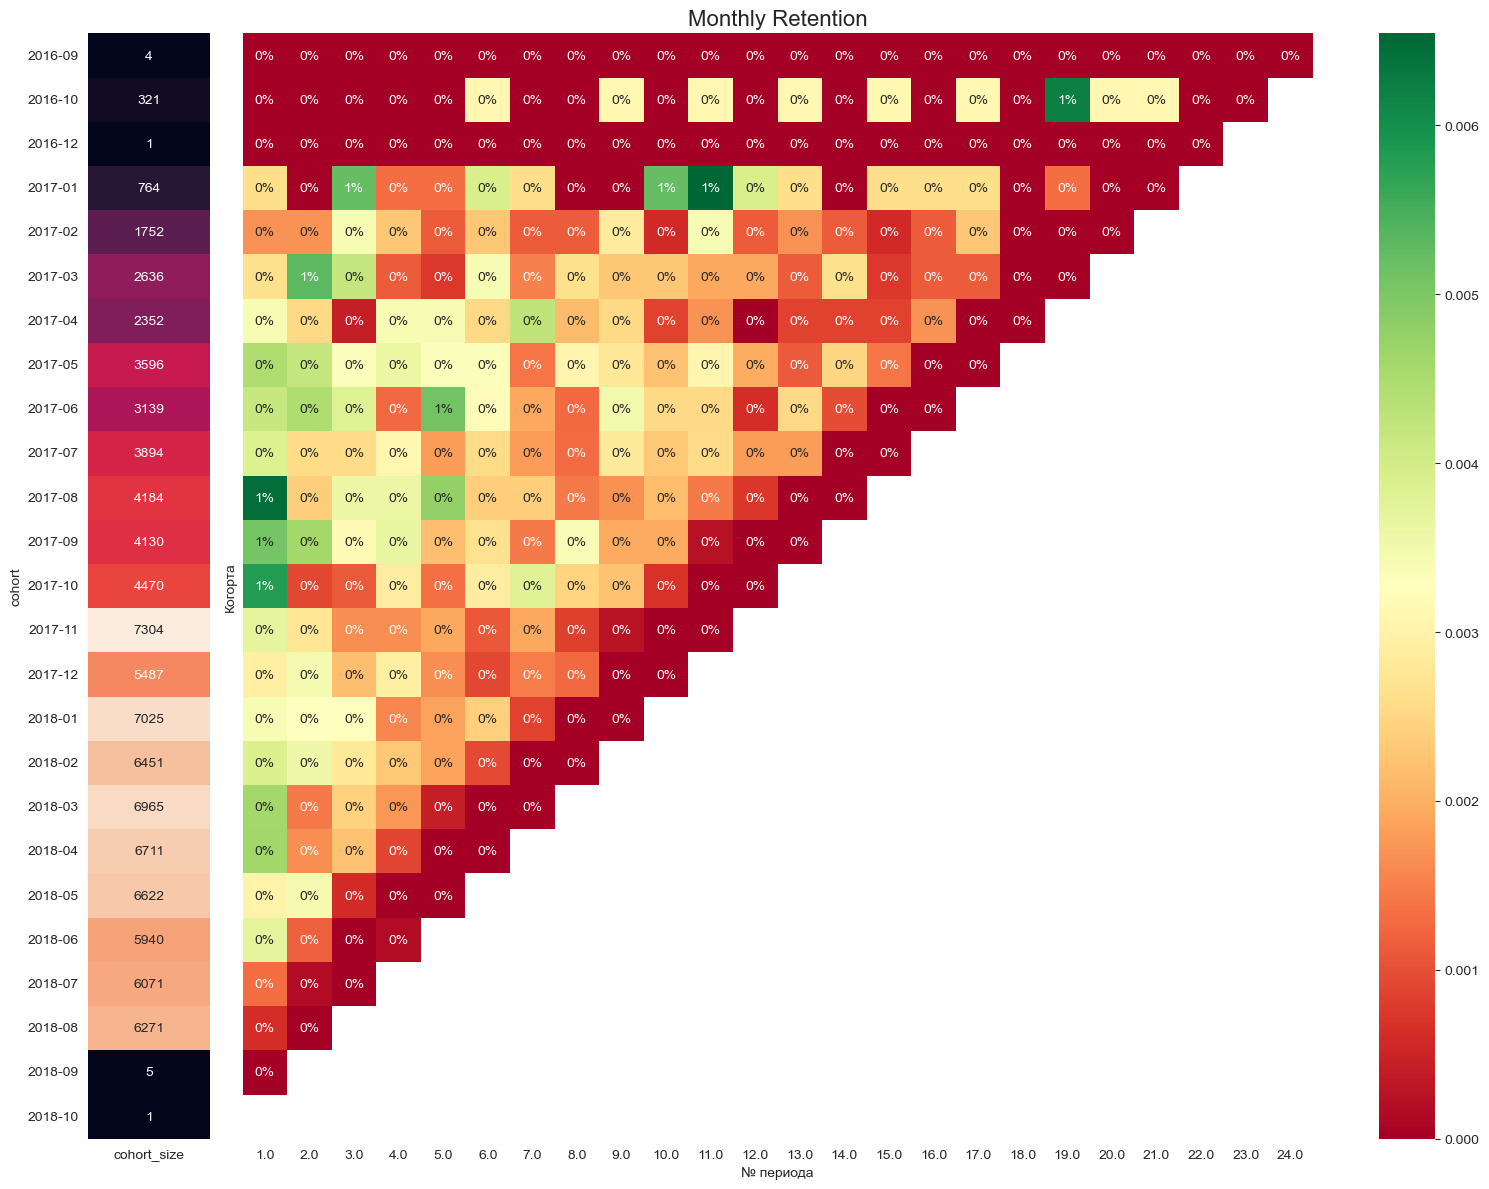

In [54]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix_without_NaN_and_0,
                mask=retention_matrix_without_NaN_and_0.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                ax=ax[0])

    fig.tight_layout()
    plt.show()

---

## Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

**Для этого вам нужно:**

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

**В рамках исследования необходимо:**

- Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
- Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
- Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

### Решение (задача 2)

В предыдущем шаге, чтобы построить визуализацию, нам пришлось исключить месяц 0 из подсчётов, потому что различие между активной аудиторией (юзеры, которые оформляли заказ) в месяц 0 было на несколько порядков выше чем в месяц 1. В дальнейшие месяцы 2,3,4 и.т.д когорты имеют примерно один порядок численности, это можно увидеть из матрицы retention.

Это значит, что у нас происходил очень активный отток аудитории после 0 месяца. Посмотрим на графиках как ведут себя когорты в 0 и в 1 месяц использования продукта.

In [55]:
# выделяем месяца 0 и 1 для отслеживания численности когорт
cohort_mounth_01 = cohort_pivot.reset_index()[['cohort', 0, 1]].rename(columns={0:'0_month',1:'1_month'})

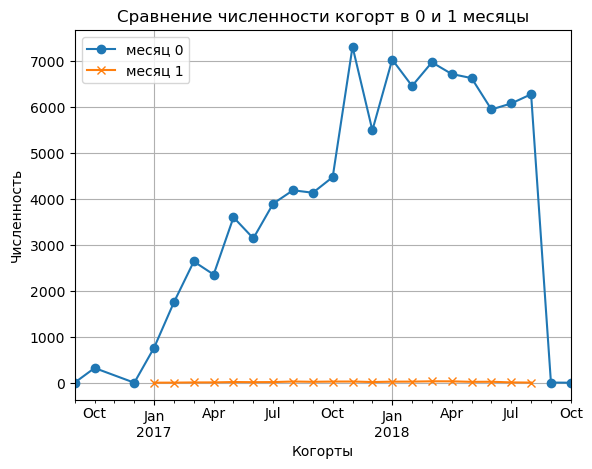

In [56]:
# построение графика
ax = cohort_mounth_01.plot(x='cohort', y='0_month', kind='line', label='месяц 0', marker='o')
cohort_mounth_01.plot(x='cohort', y='1_month', kind='line', label='месяц 1', marker='x', ax=ax)

# настройка внешнего вида графика
plt.title('Сравнение численности когорт в 0 и 1 месяцы')
plt.xlabel('Когорты')
plt.ylabel('Численность')
plt.grid(True)
plt.legend()

# отображение
plt.show()

Заметим, что некоторые когорты и вовсе не вернулись на первый месяц. Этим можно объяснить отсутствие данных по некоторым когортам (оранжевая линия не имеет данных по некоторым когортам).

Дополнительно посмотрим на график за месяц 1, так как из-за слишком большой порядковой разницы в значениях численности, данные первого месяца "занулились". Также посмотрим на показатели MAU и сравним их.

In [57]:
cohort_mounth_01

period_number_month,cohort,0_month,1_month
0,2016-09,4.0,NaN
1,2016-10,321.0,NaN
2,2016-12,1.0,NaN
3,2017-01,764.0,2.0
4,2017-02,1752.0,3.0
5,2017-03,2636.0,7.0
6,2017-04,2352.0,8.0
7,2017-05,3596.0,16.0
8,2017-06,3139.0,13.0
9,2017-07,3894.0,15.0


<Axes: ylabel='1_month'>

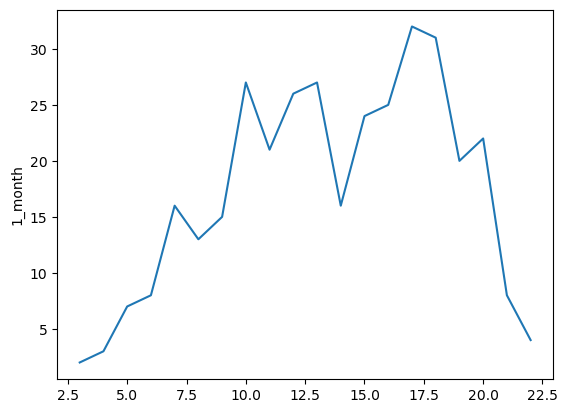

In [58]:
# отдельно рассмотрим данные первого месяца
sns.lineplot(cohort_mounth_01['1_month'])

Видим, что происходит колоссальный отток аудитории, несмотря на регулярные кратные увеличения численности новой аудитории продукта (месяц 0). Также, возвращаясь к тепловой карте, которая была построена ранее, можно увидеть, что когорты ведут себя нестабильно. Видно, что у аудитории практически отсутствует желание возвращаться к использованию продукта спустя время. Значения retention редко когда поднимается выше 0%, возвращаемость даже в первый месяц работы с продуктом катастрофически мала и колеблется ниже 2%.

Подытожим, что, исходя из данных, видно:
1) **Возвращаемость (retention) ниже 2%** для всех когорт за всё время наблюдения
2) **Аудитория постепенно сходит на нет**, юзеры не возвращаются даже на первый месяц (график со сравнением численности 0 и 1 месяцев).
3) **Численность когорт с течением времени только растёт** (график по месяцу 0). Количество оформлений заказов в нулевой месяц вырасло с 0 до ~7000 за всё время работы продукта

#### Вывод:
В данный момент **у продукта очень низкий PMF (product market fit). Можно считать, что он отсутствует.** Наш продукт даже можно назвать "дырявым ведром", потому что, несмотря на регулярный и довольно большой приток новой аудитории, возвращаемость в продукт (retention) остаётся ниже 2% и в конечном итоге падает до 0% в последние месяцы отслеживания. 

Теперь исследуем возможные причины отсутствия PMF у нашего продукта. Возможно, настолько низкий retention говорит нам о том, что наш продукт имеет проблему в выполнении главной задачи маркетплейса - доставка заказов пользователям. Предполагаю, что на каком-то этапе работы возможна поломка и наш продукт не может выполнить свою прямую задачу, поэтому юзеры не возвращаются, потому что наш продукт совсем не в состоянии закрыть потребность клиента.

In [59]:
# выделяем данные, которые нам понадобятся для изучения происходящего с продуктом
orders_info_2 = orders_df.copy()
customers_info_2 = customers_df[['customer_id','customer_unique_id']] # customer_unique_id — уникальный идентификатор пользователя

orders_data = pd.merge(orders_info_2,customers_info_2, how='left', on='customer_id') 
orders_data.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8


In [60]:
# посмотрим количество заказов по каждому статусу
orders_data.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [61]:
# посмотрим на количество пропусков в данных
orders_data.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
dtype: int64

Расшифровка колонок со временем из этой таблицы:
- order_purchase_timestamp — время создания заказа
- order_approved_at — время подтверждения оплаты заказа **(есть 160 пропусков)**
- order_delivered_carrier_date — время передачи заказа в логистическую службу **(есть 1783 пропусков)**
- order_delivered_customer_date — время доставки заказа **(есть 2965 пропусков)**
- order_estimated_delivery_date — обещанная дата доставки

#### Проблема 1 
Здесь сразу можно заметить первую проблему. По какой-то причине, сразу после создания заказа, не происходит подтверждения оплаты. Это можно увидеть по 160 пропускам в колонке с временем подтверждения оплаты заказа (order_approved_at). Подробнее посмотрим на распределение статусов по таким заказам:

In [62]:
# не подтвердили оплату
orders_data.query("order_approved_at.isna()").groupby(by='order_status', as_index=False).agg({'order_id':'nunique'})

,order_status,order_id
0,canceled,141
1,created,5
2,delivered,14


In [63]:
# доставка без подтверждения оплаты заказа
orders_data.query("order_approved_at.isna() and order_status=='delivered'")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17,8a9a08c7ca8900a200d83cf838a07e0b
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21,91efb7fcabc17925099dced52435837f
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17,e1f01a1bd6485e58ad3c769a5427d8a8
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31,7e1a5ca61b572d76b64b6688b9f96473
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20,c8822fce1d0bfa7ddf0da24fff947172
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01,6ff8b0d7b35d5c945633b8d60165691b
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27,2e0a2166aa23da2472c6a60c4af6f7a6
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22,c4c0011e639bdbcf26059ddc38bd3c18
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16,d49f3dae6bad25d05160fc17aca5942d
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20,5a4fa4919cbf2b049e72be460a380e5b


Видим что среди заказов с неподтверждённой оплатой есть даже такие, которые были доставлены. Походже имеет место некий сбой или баг. Мы не должны доставлять заказы с неподтверждённой оплатой. 

#### Проблема 2
Также можно увидеть что колонка с временем передачи заказа в логистическую службу (order_delivered_carrier_date) тоже имеет много пропусков. Целых 1783 штук. Рассмотрим подробнее эту проблему:

In [64]:
# не подтвердили оплату
orders_data.query("order_delivered_carrier_date.isna()").groupby(by='order_status', as_index=False).agg({'order_id':'nunique'})

,order_status,order_id
0,approved,2
1,canceled,550
2,created,5
3,delivered,2
4,invoiced,314
5,processing,301
6,unavailable,609


In [65]:
# сборка без передачи в логистическую службу
orders_data.query("order_delivered_carrier_date.isna() and order_status=='processing'")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,9f269af9c49244f6ba4a46985a3cfc2e
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09,07d5b1f9bdd053347f0213187b343ac9
741,6a6c7d523fd59eb5bbefc007331af717,d954782ec6c0e911292c8a80757ef28d,processing,2017-11-24 20:09:33,2017-11-24 23:15:15,NaT,NaT,2017-12-20,2adaff8e437d7153f3326cf14187d821
1192,745e1d4a7f8c4b548881788d4113bb1d,7198d7088442e4ddfe553353d8ddc957,processing,2017-11-17 06:34:36,2017-11-18 02:15:40,NaT,NaT,2017-12-12,11160ccb67a77abe36dd062bd2701a04
1516,1d52ba7197c7acebbb4f826f6585536f,c9c7fe860d602373a9e93f8bfe9d877a,processing,2017-02-13 18:32:55,2017-02-13 18:43:55,NaT,NaT,2017-04-04,fd0c94860d35a337f8954558e9e0181c
...,...,...,...,...,...,...,...,...,...
97400,dcdfc540e42725663242bb884c28f0a6,38972104038aa68fcc61277dbf6e7ca9,processing,2017-10-30 10:46:44,2017-10-30 11:09:55,NaT,NaT,2017-11-23,5675ed0d10724c31f70cb0a3bca7c1ed
97666,e471815e7114cdb474064f7dbb1a8b67,092c9316ae71b2fe43e526043f351967,processing,2017-12-20 11:00:02,2017-12-20 11:10:43,NaT,NaT,2018-02-02,92b48641632e617da2beb5e94004bfce
98089,10951d02d64917a34959abeb8130601e,3e6754e591ff3568ccc5bf69a649918c,processing,2018-02-13 21:02:02,2018-02-15 04:11:21,NaT,NaT,2018-03-13,4b6590937ab57d114e9a1827da91c88f
99140,aea0db338150b526dde24f6fd953a5ed,379a02efdc6a56bd27f99b95fc2f6c06,processing,2017-12-26 21:56:13,2017-12-26 22:05:26,NaT,NaT,2018-01-26,43fb4e33ebe4ac765e99c7b57e5d6940


In [66]:
# оплата без передачи в логистическую службу
orders_data.query("order_delivered_carrier_date.isna() and order_status=='invoiced'")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,c7f8d7b1fffc946d7069574f74c39f4e
455,38b7efdf33dd5561f4f5d4f6e07b0414,021e84751ba0ead75b6d314a6ead88d9,invoiced,2017-08-01 18:17:41,2017-08-01 18:32:30,NaT,NaT,2017-08-28,9a58c55c10b4eb6c69fb0874d8beb466
1833,51b0dccc8596ce37a930dff2d63a10a2,31bf1057b00f14804278590bbac18b1b,invoiced,2017-05-05 22:34:48,2017-05-05 22:45:12,NaT,NaT,2017-06-06,561cfc00b430b16ff8e8d36429d709e7
2116,5504eaa5a86eb25fa666cf2e6b96c701,a30be38e1ed0ffb39b318bf1d15e98d9,invoiced,2017-11-29 08:33:06,2017-11-29 08:56:23,NaT,NaT,2017-12-20,43f17abb82aa3e528eb5fbacc9b92c77
...,...,...,...,...,...,...,...,...,...
98414,41ad2ae32ee66c07ef3b0301ba02ad27,5c7f8d14a0a12198d1d07167d7d343b3,invoiced,2017-11-24 15:54:47,2017-11-24 19:33:24,NaT,NaT,2017-12-18,db5edf92e08b477b2134569ac8a8b644
98624,9ffb325177b96c422447e3b9ee9a6270,e4079117ea0dc8bc27274e34c4796515,invoiced,2018-05-10 19:11:18,2018-05-10 19:37:27,NaT,NaT,2018-06-05,78901a5f769ea6acdeaac167cb8b8aae
98845,021dac6e3120485db6a77474aa21b979,c40f7f00e91eb8a0da1e58484380a796,invoiced,2017-11-24 22:46:09,2017-11-25 01:53:42,NaT,NaT,2017-12-15,5e107141755c25a665b011009bc254b9
99031,c526fe83c01c48066394ff5d81f9ab9a,6c678c38f3a0874b7bfeeb2d5fb22876,invoiced,2018-08-07 11:11:30,2018-08-07 11:25:01,NaT,NaT,2018-08-17,1bc908dc0f4755b364972526cb872ae2


Видим что многие заказы даже с 2017 года так и не были доставлены и не были переданы в логистическую службу, они всё ещё в процессе сборки. Так быть не должно, это ещё раз показывает, что в нашей системе имеется сбой. Также ещё с 2017 года у нас имеются заказы, которые были оплачены клиентами, но так и не доставлены в логистическую службу.

У продукта не отлажены процессы отслеживания статусов заказов. По первому же взгляду на систему мы видим, что клиенты получают неудовлетворительный опыт взаимодействия с нашим магазином. Некоторые заказы были оплачены и собраны, но так и не доехали до своих адресатов спустя даже очень длительное количество времени. Думаю, нашему маркетплейсу в первую очередь нужно отладить корректно процессы исполнения главной функции - доставки заказов и процессов связанных с оформлением заказов. 

---

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

**В первую очередь необходимо:**

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

- Первая метрика должна отражать рост объёма продаж маркетплейса.
- Вторая — показывать объем аудитории, которой продукт доставляет ценность.
- Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
- Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
- Пятая — отражать денежное выражение вовлеченности клиента.
  
**Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.**

### Решение (задача 3)

**1. GVM (Gross Merchandise Value) — общий объем оборота товаров**

Первой метрикой, которая будет отражать рост объёма продаж будет GVM (Gross Merchandise Value). Она фиксирует объем созданных заказов до того, как из них вычтут возвраты, отмены и другие расходы. Благодаря этой метрике мы сможем как раз фиксировать изменения объёма продаж, так как объём продаж в нашем случае = объём оформленных на маркетплейсе заказов.

Рассчёт будем производить по формуле:

*GVM = общее_количество_продаж_за_месяц * средний_чек_одного_заказа_за_месяц*

In [67]:
# возьмём нужные данные для подсчёта метрики из таблицы olist_orders_dataset
orders_tab = orders_df.copy()[['order_id','order_purchase_timestamp']]

In [68]:
# возьмём нужные данные для подсчёта метрики из таблицы olist_order_items_dataset
order_items_tab = order_items_df.copy()[['order_id','order_item_id','product_id','price']]

In [69]:
# объединяем все нужные данные для подсчёта метрики в единую таблицу
orders_and_items = pd.merge(order_items_tab,orders_tab,how='left',on='order_id')

In [70]:
# проверим что всё корректно и без пропусков в данных приджойнолось
orders_and_items.isna().sum()

order_id                    0
order_item_id               0
product_id                  0
price                       0
order_purchase_timestamp    0
dtype: int64

In [71]:
# извлекаем месяц из даты оформления заказа
orders_and_items['purchase_month'] = orders_and_items['order_purchase_timestamp'].dt.to_period(freq='M')
orders_and_items.head(3)

,order_id,order_item_id,product_id,price,order_purchase_timestamp,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.9,2017-09-13 08:59:02,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.9,2017-04-26 10:53:06,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.0,2018-01-14 14:33:31,2018-01


In [72]:
# находим общее количество продаж (оформлений уникальных заказов) для каждого месяца
purchases_per_month = orders_and_items.groupby(by='purchase_month', as_index=False).agg(orders_count=('order_id','nunique'))

In [73]:
# находим общую стоимость для каждого заказа
purchases_total_sum = orders_and_items.groupby(by=['purchase_month','order_id'], as_index=False).agg(total_price=('price','sum'))

# считаем AOV (Average Order Value) — средний чек заказа для каждого месяца
aov_per_month = purchases_total_sum.groupby(by='purchase_month', as_index=False).agg(aov=('total_price','mean'))

In [74]:
# объединяем данные по количеству заказов и по среднему чеку в месяц
purcases_count_and_total = pd.merge(purchases_per_month, aov_per_month, how='left', on='purchase_month')
purcases_count_and_total.head(3)

,purchase_month,orders_count,aov
0,2016-09,3,89.120000
1,2016-10,308,160.739156
2,2016-12,1,10.900000


In [75]:
# считаем GMV (помесячный объём продаж) в тысячах
purcases_count_and_total['gmv_score'] = (purcases_count_and_total.orders_count * purcases_count_and_total.aov) / 1000
purcases_count_and_total.head(3)

,purchase_month,orders_count,aov,gmv_score
0,2016-09,3,89.120000,0.26736
1,2016-10,308,160.739156,49.50766
2,2016-12,1,10.900000,0.01090


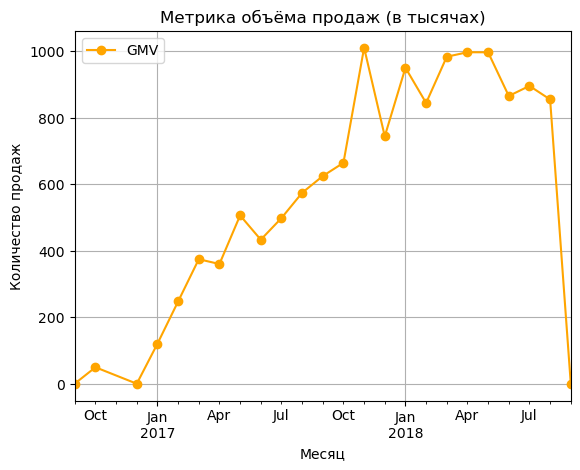

In [76]:
# построение графика GMV
ax = purcases_count_and_total.plot(x='purchase_month', y='gmv_score', kind='line', label='GMV', marker='o', color='orange')

# настройка внешнего вида графика
plt.title('Метрика объёма продаж (в тысячах)')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.legend()

# отображение
plt.show()

**2. MAU (Monthly Active Users) - количество уникальных пользователей в месяц**

Вторая метрика для отслеживания объёма аудитории, которой продукт доставляет - MAU (Monthly Active Users). Она будет отражать количество уникальных пользователей, которые оформляют заказы (т.е. совершают нужное нам активное действие) каждый месяц.

Рассчёт будем производить по формуле:

*MAU = количество_уникальных_пользователей_в_месяц*

In [77]:
# выделяем данные, которые нам понадобятся для рассчёта MAU
orders_info_mau = orders_df[['customer_id','order_purchase_timestamp']] # order_purchase_timestamp - время создания заказа
customers_info_mau = customers_df[['customer_id','customer_unique_id']] # customer_unique_id — уникальный идентификатор пользователя

orders_time_customer = pd.merge(orders_info_mau,customers_info_mau, how='left', on='customer_id') 

In [78]:
# оставим только необходимые для подсчёта MAU столбцы
orders_time_customer = orders_time_customer[['order_purchase_timestamp','customer_unique_id']]

In [79]:
# извлекаем месяц из даты оформления заказа
orders_time_customer['purchase_month'] = orders_time_customer['order_purchase_timestamp'].dt.to_period(freq='M')

In [80]:
orders_time_customer.head()

,order_purchase_timestamp,customer_unique_id,purchase_month
0,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10
1,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07
2,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08
3,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11
4,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02


In [81]:
# подсчитаем MAU — количество уникальных пользователей в месяц
count_per_month = orders_time_customer.groupby(by='purchase_month', as_index=False).agg(mau_score=('customer_unique_id','nunique'))
count_per_month.head(3)

,purchase_month,mau_score
0,2016-09,4
1,2016-10,321
2,2016-12,1


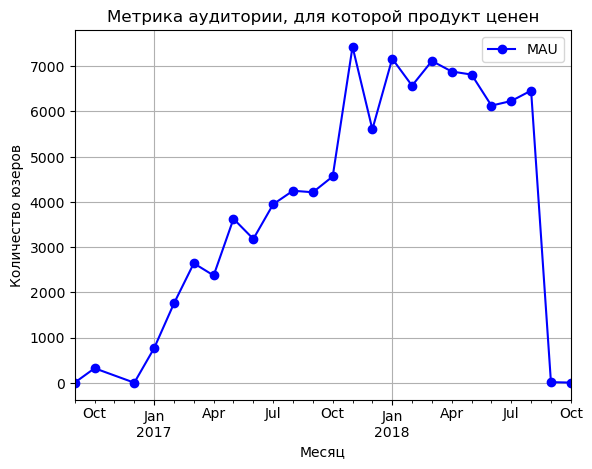

In [82]:
# построение графика MAU
ax = count_per_month.plot(x='purchase_month', y='mau_score', kind='line', label='MAU', marker='o', color='blue')

# настройка внешнего вида графика
plt.title('Метрика аудитории, для которой продукт ценен')
plt.xlabel('Месяц')
plt.ylabel('Количество юзеров')
plt.grid(True)
plt.legend()

# отображение
plt.show()

**3. CAC (Customer Acquisition Cost) Payback Period - срок окупаемости затрат на привлечение клиента**

Эта метрика покажет сколько прибыли нужно принести юзеру, чтобы он полностью покрыл расходы на собственное привлечение. Метрика отражает заинтересованность новых клиентов. Если клиенты видят ценность в продукте и быстро совершают повторные покупки, стоимость их привлечения окупается быстрее. Именно так мы можем измерить их заинтересованность. 

Рассчёт будем производить по формуле:

*CAC_payback_period = стоимость_привлечения_одного_клиента / средний_доход_от_одного_клиента_в_месяц * маржинальность*

где
- стоимость_привлечения_одного_клиента:
  
  || CAC (Customer Acquisition Cost) = сумма_затрат_на_привлечение_новых_клиентов_за_месяц / количество_новых_кливентов_за_месяц ||

  
- средний_доход_от_одного_клиента_в_месяц - все деньги, которые юзер нам заплатил до вычета наших затрат (включая комиссии и.т.д):

  || ARPU (Average Revenue Per User) = общий_доход_за_месяц / общее_количество_клиентов_за_месяц ||
  
- маржинальность (Gross Margin %) - какой процент от дохода остается компании после выплаты всех переменных затрат

Чем меньше времени проходит от момента появления нового клиента до того момента, когда новый клиент начинает "зарабатывать" для нас, тем больше интереса наш продукт вызывает. Значит, клиент заинтересован чаще удовлетворять свою потребность в заказе именно с помощью нашего продукта.



К сожалению, **нам не посчитать эту метрику на данных, которые есть в проекте**, потому что у нас нет никакой информации о затратах, которые пошли на привлечение наших новых клиентов, а также отсутствует информация о переменных затратах и маржинальности.

**4. Retention Rate (1-month) — коэффициент удержания пользователей за первый месяц** 

Вовлечённость в продолжение использования будем оценивать по поведению значения метрики удержания за первый месяц. Её показатель будет хорошо демонстрировать есть ли желание у юзеров возвращаться в наш продукт и продолжать его использование после нулевого месяца-знакомства

In [83]:
# возьмём нужные для метрики данные из матрицы retention
retention_month_1 = retention_matrix_without_NaN[1].reset_index().rename(columns={1:'retantion_score'})

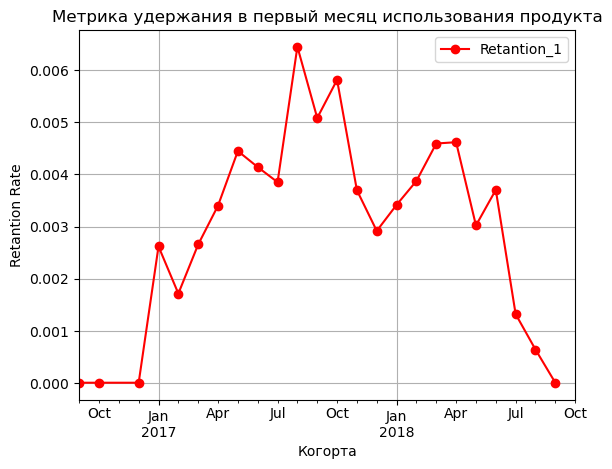

In [84]:
# построение графика MAU
ax = retention_month_1.plot(x='cohort', y='retantion_score', kind='line', label='Retantion_1', marker='o', color='red')

# настройка внешнего вида графика
plt.title('Метрика удержания в первый месяц использования продукта')
plt.xlabel('Когорта')
plt.ylabel('Retantion Rate')
plt.grid(True)
plt.legend()

# отображение
plt.show()

**5. LTV (Lifetime Value) — прибыль, которую мы получаем за всю жизнь пользователя**

Поможет отразить денежное выражение вовлеченности клиента

Рассчёт будем производить по формуле:

*LTV = Average Profit per Customer / Lifetime*

То есть посчитаем отношение среднего дохода, который мы получаем с клиента на среднюю "продолжительность жизни" клиента в продукте. Допустим, что Lifetime = 1 месяц (допущение, которое возможно по условиям задачи)

In [85]:
orders_per_users = pd.merge(order_items_df, pd.merge(orders_df,customers_df[['customer_id','customer_unique_id']],how='left',on='customer_id'), how='left', on='order_id')
orders_per_users = orders_per_users[['order_id','order_item_id','price','order_purchase_timestamp','customer_unique_id']]
# извлекаем месяц из даты оформления заказа
orders_per_users['purchase_month'] = orders_per_users['order_purchase_timestamp'].dt.to_period(freq='M')

In [86]:
# находим общую сумму заказов для каждого юзера в месяц
users_total_sum = orders_per_users.groupby(by=['purchase_month','customer_unique_id'],as_index=False).agg(profit_per_customer=('price','sum'))
# считаем Average Profit per Customer — средний доход с юзера для каждого месяца
# так как мы допустили ранее, что Lifetime = 1, то LTV = Average Profit per Customer * 1. Следовательно, LTV = Average Profit per Customer
ap_per_customer = users_total_sum.groupby(by='purchase_month', as_index=False).agg(ltv=('profit_per_customer','mean'))
ap_per_customer.head(3)

,purchase_month,ltv
0,2016-09,89.120000
1,2016-10,162.320197
2,2016-12,10.900000


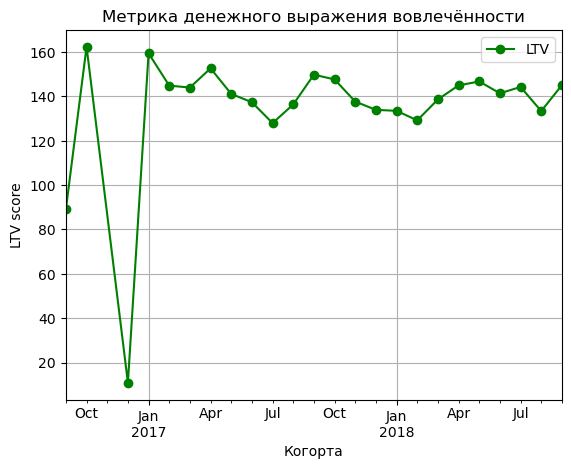

In [87]:
# построение графика MAU
ax = ap_per_customer.plot(x='purchase_month', y='ltv', kind='line', label='LTV', marker='o', color='green')

# настройка внешнего вида графика
plt.title('Метрика денежного выражения вовлечённости')
plt.xlabel('Когорта')
plt.ylabel('LTV score')
plt.grid(True)
plt.legend()

# отображение
plt.show()

---

## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

**Для перевода метрики в Impact воспользуйтесь следующей шкалой:**

<table>
    <tr>
        <th>Impact</th>
        <th>1</th>
        <th>2</th>
        <th>3</th>
        <th>4</th>
        <th>5</th>
        <th>6</th>
        <th>7</th>
        <th>8</th>
        <th>9</th>
        <th>10</th>
        <tr>
            <td>Значение метрики</td>
            <td>| 0 - 50</td>
            <td>| 51 - 150</td>
            <td>| 151 - 350</td>
            <td>| 351 - 750</td>
            <td>| 751 - 1 550</td>
            <td>| 1 551 - 3 150</td>
            <td>| 3 151 - 6 350</td>
            <td>| 6 351 - 12 750</td>
            <td>| 12 751 - 25 550</td>
            <td>| 25 551 - 51 150 |</td>
        </tr>
    </tr>
</table>


<table>
    <tr>
        <th>№ гипотезы</th>
        <th>Гипотеза</th>
        <th>Impact</th>
        <th>Confidence</th>
        <th>Ease</th>
        <th>ICE</th>
        <tr>
            <td>№ 1</td>
            <td>Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.	</td>
            <td>7</td>
            <td>8</td>
            <td>6</td>
            <td>336</td>
        </tr>
        <tr>
            <td>№ 2</td>
            <td>Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.</td>
            <td>6</td>
            <td>10</td>
            <td>4</td>
            <td>240</td>
        </tr>
        <tr>
            <td>№ 3</td>
            <td>Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.</td>
            <td>6</td>
            <td>5</td>
            <td>9</td>
            <td>270</td>
        </tr>
    </tr>
</table>

### Решение (задача 4)

In [88]:
# рассчёт конверсии в повторный заказ
convertion_rate = retention_month_1.retantion_score.median()
convertion_rate

0.003408865325489626

In [89]:
# подготовим данные за июнь 2017 года для работы с заданием
june_2017_order_data = orders_df.copy()
june_2017_order_data = june_2017_order_data[(june_2017_order_data['order_purchase_timestamp'].dt.month == 6) & (june_2017_order_data['order_purchase_timestamp'].dt.year == 2017)]
june_2017_order_data.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
59,2edfd6d1f0b4cd0db4bf37b1b224d855,241e78de29b3090cfa1b5d73a8130c72,delivered,2017-06-13 21:11:26,2017-06-15 03:05:45,2017-06-16 14:55:37,2017-06-19 18:51:28,2017-07-06
117,1c35ac660d7ef6691b25d20df3d6eccb,68c85132eb3b96fbe6cbddc09a568d24,delivered,2017-06-27 23:11:57,2017-06-27 23:35:09,2017-06-28 14:28:00,2017-06-29 10:16:35,2017-07-10
188,74ebfa44a323c96a7760bd693d690a3d,13fd7ce9f08449dec2533119379a2527,delivered,2017-06-16 00:22:49,2017-06-16 00:35:26,2017-06-16 15:37:52,2017-06-26 13:49:52,2017-07-18


In [90]:
# количество всех отменённых заказов в июне 2017
june_2017_canceled = june_2017_order_data.query("order_status == 'canceled'").order_id.nunique()

In [91]:
# количество всех доставленных заказов в июне 2017
june_2017_delivered = june_2017_order_data.query("order_status == 'delivered'").order_id.nunique()

#### Проверим гипотезу № 1

In [92]:
june_2017_delivered_impact = june_2017_delivered + june_2017_canceled
june_2017_delivered_impact

3151

У гипотезы №1 получилось 7 очков impact

In [93]:
# считаем ICE score для первой гипотезы
impact_1 = 7
confidence_1 = 8
ease_1 = 6

ice_score_1 = impact_1 * confidence_1 * ease_1
ice_score_1

336

#### Проверим гипотезу № 2

In [94]:
june_2017_delivered + june_2017_order_data.query('order_estimated_delivery_date < order_delivered_customer_date').order_id.nunique() * convertion_rate

3135.412472704384

У гипотезы №2 получилось 6 очков impact

In [95]:
# считаем ICE score для второй гипотезы
impact_2 = 6
confidence_2 = 10
ease_2 = 4

ice_score_2 = impact_2 * confidence_2 * ease_2
ice_score_2

240

#### Проверим гипотезу № 3

In [96]:
june_2017_delivered + pd.merge(june_2017_order_data,customers_df,how='left', on='customer_id').groupby(by='customer_unique_id', as_index=False).agg(orders_count=('order_id','nunique')).query('orders_count == 1').customer_unique_id.count() * convertion_rate 

np.float64(3145.6220243542257)

У гипотезы №3 получилось 6 очков impact

In [97]:
# считаем ICE score для третьей гипотезы
impact_3 = 6
confidence_3 = 5
ease_3 = 9

ice_score_3 = impact_3 * confidence_3 * ease_3
ice_score_3

270

Итог: **Делаем выбор в пользу гипотезы № 1**, так как она имеет наивысший скор по ICE

---

## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

**Продакт попросил вас:**

- Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
- Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

### Решение (задача 5)

Гипотеза: "Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен."

1) Как мы хотим влиять?
Исправление бага в системе процессинга заказов

2) Какая проблема клиента?
Отмены заказов из-за бага в нашей системе

3) Какой сегмент клиентов?
Все клиенты, оформившие заказ на платформе

4) Какой эффект ждём?
Увеличить количество доставленных заказов. Избавиться от отменённых заказов

Целевая метрика: **Среднее количество успешно доставленных заказов на клиента**

- **Чувствительна:** Средний показатель количества успешных заказов на клиента хорошо будет отражать изменения, потому что будет отражать не только тенденцию количества отмен, но и желание клиентов возвращаться к нашему продукту после устранения бага. Среднее хорошо отражает изменения, будет видно даже небольшой эффект на данных
- **Достоверна:** Мы можем посчитать эту метрику на тех данных, которые у нас имеются (например, по каждому месяцу мы сможем посчитать отношение количества успешно доставленных заказов для каждого уникального клиента и общего количества доставленных заказов для каждого уникального клиента, а затем найти среднее среди всех таких значений по каждому клиенту за месяц. Таким образом ежемесячно можно отслеживать метрику).
- **Интерпретируема:**  Мы сможем оценить продуктовое изменение, которое было нами сделано, так как продуктовое изменение у нас направлено именно на увеличение количества доставленных заказов. 

Прокси-метрика: **Доля отменённых заказов = Конверсия в отменённые заказы**

- **Чувствительна:** Конверсионные метрики чувствительны и хорошо подходят для экспериментов
- **Достоверна:** Её можно посчитать на наших данных.
- **Интерпретируема:** Целью нашего изменение также является уменьшение количества отмен. Эту метрику будет легко интерпретировать при отслеживании уровня отменённых заказов на платформе, а также мы довольно оперативно сможем проводить подсчёты и наблюдать за изменениями после исправления бага

Барьерная метрика: **Среднее время доставки заказа**

- **Чувствительна:** Она чувствительна: среднее хорошо отражает изменения
- **Достоверна:** Её можно посчитать на наших данных.
- **Интерпретируема:** Наше изменение направлено на увеличение количества доставленных заказов и избавление от отмен. Следовательно, наше улучшение также будет направлено на увеличение количества заказов. Если наше изменение приведёт к проблемам на каком-либо из этапов работы магазина (например, задержку товаров на складе из-за недостаточной логистической мощи компании), то есть к таким моментам, когда ресурсов нашего продукта перестанет хватать на обслуживание увеличенного объёма заказов, то мы сможем отследить это по данной метрике. Она просигнализирует, если введённое нами изменение начнёт аффектить на продукт как в сторону улучшения (сокращение времени доставки), так и ухудшения (увеличение времени доставки)


---

## Задача 6. Вот и подошёл к концу ваш первый этап работы аналитиком в команде маркетплейса. Теперь необходимо поделиться результатами проведённой работы с компанией.


Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет для Пети.
Изложите его в комментариях в ipynb-файле или описании мердж-реквеста.

**Структура должна выглядеть следующим образом:**

- формализация проблемы продукта: что не так и как вы это поняли?
- общие выводы по итогу исследования на основе результатов, полученных в заданиях 1-5;
- рекомендации по продукту.

### Решение (задача 6)

Основная задача при проведении анализа работы маркетплейса состояла в том, чтобы **выяснить причину проблемы со стагнацией выручки.** Выручка продукта стояла на месте насколько месяцев. Такое поведение можно объяснить либо проблемой с количеством привлекаемой аудитории, либо проблемой с качеством нашего продукта.

Проведение анализа мы начали с разделения клиентов на группы (отталкиваясь от месяца, когда клиент совершил первый заказ). **Нужно было посмотреть сколько новых пользователей ежемесячно приходит в наш продукт и как меняется поведение каждой группы по отношению к продукту через время.** Таким образом мы сможем получить более широкое представление о качестве продукта, наблюдая как ведут себя более новые пользователи и более старые с течением времени.

Изучая поведение аудитории, мы увидели, что с каждым месяцом приток новых клиентов был только выше, пользователи проявляли массовый интерес и активно делали первые заказы. Однако, к сожалению, мы выяснили, что, почти сразу после знакомства с нашим продуктом (через месяц после первого использования), интерес к продукту резко падал. **Удержание пользователей в продукте не превышало 2% за всё время существования нашего продукта. Это критически маленький показатель удержания. Получилась такая ситуация, что аудитория росла, но наш продукт не мог закрыть потребность пользователей в получении заказов.** Такие продукты можно назвать "дырявым ведром".

Было выявлено, что **самой актуальной проблемой продукта в данный момент является баг в нашей системе процессинга заказов.** Внутриняя система магазина работала некорректно, поэтому заказы клиентов не проходили полный путь от оформления заказа до доставки, застревая и теряясь где-то между этапами. Наш продукт имеет проблемы с выполнением прямой функции  - доставки заказов. Поэтому рост аудитории никак не сказывался на нашей выручке. Клиенты уходили сразу после знакомства с нашим магазином, наш продукт имеет слишком низкую ценность для аудитории.

**Главной рекомендацией будет исправление бага в системе процессинга заказов.** Только когда качество нашей внутренней системы улучшится и она начнёт работать без сбоев, мы сможем говорить о создании ценности для нашей аудитори. 